# Practical No. 03: Autoencoder and Variational Autoencoder for Image Reconstruction

**Objective:** Build an Autoencoder (AE) and a Variational Autoencoder (VAE) for image reconstruction and generation, then compare their performance.

**Dataset:** MNIST handwritten digits

**Tasks covered:**
1. Load and preprocess the dataset.
2. Build and train an Autoencoder.
3. Reconstruct test images using the Autoencoder.
4. Build and train a Variational Autoencoder.
5. Reconstruct test images using the VAE.
6. Generate new images from the VAE latent space.
7. Compare reconstruction quality using MSE and visual results.


In [1]:
# Install dependencies if running in Google Colab
# Uncomment the next line only if TensorFlow is not already installed.
# !pip install -q tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 1. Load and preprocess MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28, 1)
Testing images : (10000, 28, 28, 1)


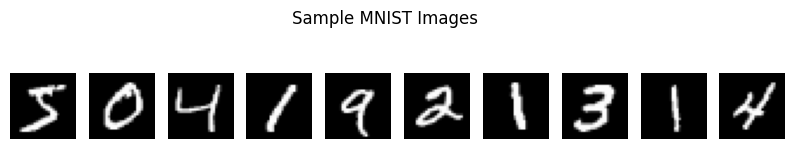

In [2]:
# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixels from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

# Display sample images
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()


## 2. Autoencoder

The Autoencoder contains:
- **Encoder:** converts the input image into a compact latent representation.
- **Latent space:** stores important image features.
- **Decoder:** reconstructs the original image from the latent representation.

**Architecture:** 28×28×1 → 16×16×32 → 8×8×64 → Dense(32) → Decoder → 28×28×1


In [3]:
# Autoencoder
latent_dim = 32

# Encoder
encoder_input = keras.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(encoder_input)
x = layers.Conv2D(64, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent_vector")(x)

encoder = keras.Model(encoder_input, latent, name="encoder")
encoder.summary()

# Decoder
decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same", strides=2)(x)
decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

# Complete Autoencoder
ae_input = keras.Input(shape=(28, 28, 1))
ae_output = decoder(encoder(ae_input))
autoencoder = keras.Model(ae_input, ae_output, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="mse")


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │       100,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,200 (465.62 KB)

 Trainable params: 119,200 (465.62 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,169 (621.75 KB)

 Trainable params: 159,169 (621.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train Autoencoder
ae_history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 225ms/step - loss: 0.0397 - val_loss: 0.0089
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 226ms/step - loss: 0.0071 - val_loss: 0.0058
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 221ms/step - loss: 0.0054 - val_loss: 0.0050
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 224ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 221ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 222ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 222ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 223ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 223ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 227ms/step - loss: 0.0035 - val_loss: 0.0036


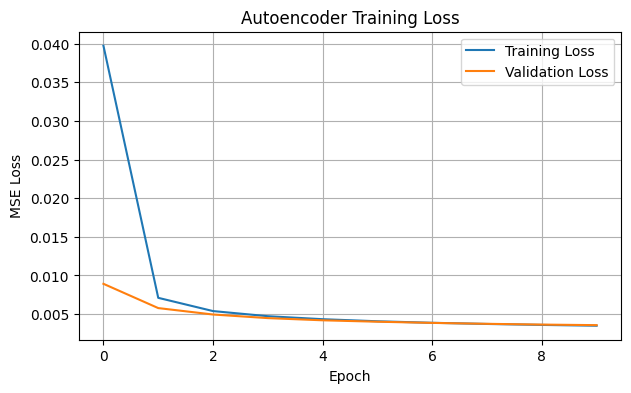

In [5]:
# Plot Autoencoder training loss
plt.figure(figsize=(7, 4))
plt.plot(ae_history.history["loss"], label="Training Loss")
plt.plot(ae_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()


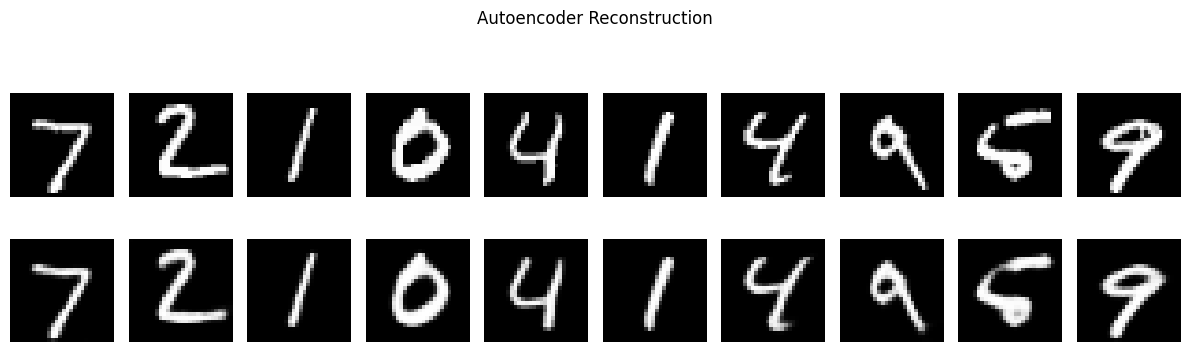

Autoencoder Test MSE: 0.0035046705


In [6]:
# Reconstruct test images using Autoencoder
ae_reconstructed = autoencoder.predict(x_test[:10], verbose=0)

plt.figure(figsize=(12, 4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original", fontsize=10)

    # Reconstruction
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(ae_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("AE", fontsize=10)

plt.suptitle("Autoencoder Reconstruction")
plt.tight_layout()
plt.show()

ae_mse = np.mean((x_test[:1000] - autoencoder.predict(x_test[:1000], verbose=0)) ** 2)
print("Autoencoder Test MSE:", ae_mse)


## 3. Variational Autoencoder (VAE)

Unlike a normal Autoencoder, a VAE learns a **probability distribution** in the latent space.

The encoder produces:
- **μ (mean)**
- **log(σ²) (log variance)**

A latent vector is sampled using the reparameterization trick:

**z = μ + exp(0.5 × log_var) × ε**, where ε follows a standard normal distribution.

The VAE loss consists of:
1. Reconstruction loss
2. KL-divergence loss


In [7]:
# VAE Encoder
latent_dim = 2

vae_encoder_input = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(vae_encoder_input)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sample_latent(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sample_latent, name="z")([z_mean, z_log_var])

vae_encoder = keras.Model(
    vae_encoder_input, [z_mean, z_log_var, z], name="vae_encoder"
)
vae_encoder.summary()


Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# VAE Decoder
vae_decoder_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(vae_decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

vae_decoder = keras.Model(
    vae_decoder_input, vae_decoder_output, name="vae_decoder"
)
vae_decoder.summary()


Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Custom VAE model with reconstruction + KL divergence loss
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Binary cross-entropy reconstruction loss
            bce = keras.losses.binary_crossentropy(data, reconstruction)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=(1, 2)))

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        bce = keras.losses.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=(1, 2)))

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam())


In [10]:
# Train VAE
vae_history = vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, None),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 231ms/step - kl_loss: 4.1468 - loss: 203.1051 - reconstruction_loss: 198.9584 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 230ms/step - kl_loss: 5.1318 - loss: 165.0070 - reconstruction_loss: 159.8752 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 228ms/step - kl_loss: 5.6185 - loss: 157.6515 - reconstruction_loss: 152.0331 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - kl_loss: 5.8509 - loss: 154.6153 - reconstruction_loss: 148.7644 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 229ms/step - kl_loss: 6.0027 - loss: 152.5281 - reconstruction_loss: 146.5254 - val_kl_loss: 0.0000e+00 - val_loss:

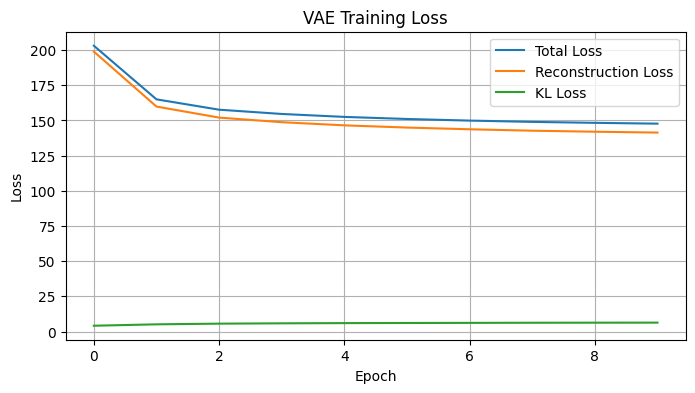

In [11]:
# Plot VAE losses
plt.figure(figsize=(8, 4))
plt.plot(vae_history.history["loss"], label="Total Loss")
plt.plot(vae_history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(vae_history.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()


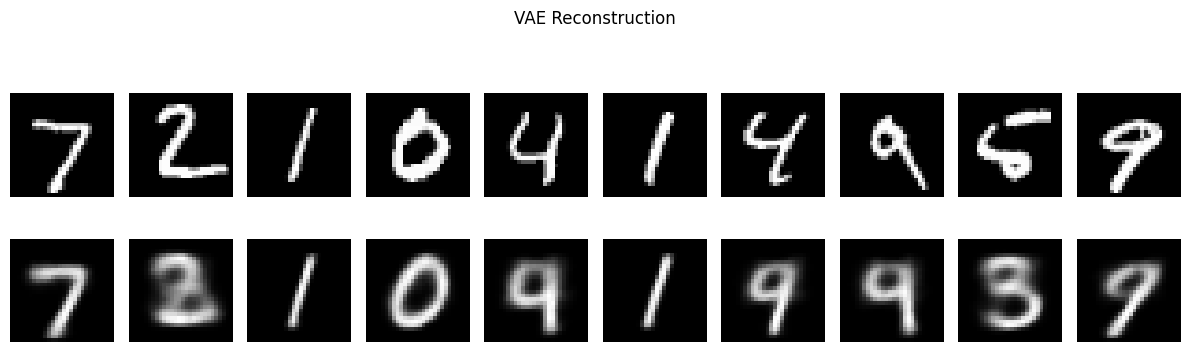

VAE Test MSE: 0.040677857


In [12]:
# Reconstruct test images using VAE
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(x_test[:10], verbose=0)
vae_reconstructed = vae_decoder.predict(z_test, verbose=0)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original", fontsize=10)

    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(vae_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("VAE", fontsize=10)

plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()

vae_reconstructed_1000 = vae_decoder.predict(
    vae_encoder.predict(x_test[:1000], verbose=0)[2], verbose=0
)
vae_mse = np.mean((x_test[:1000] - vae_reconstructed_1000) ** 2)
print("VAE Test MSE:", vae_mse)


## 4. Generate New Images using VAE

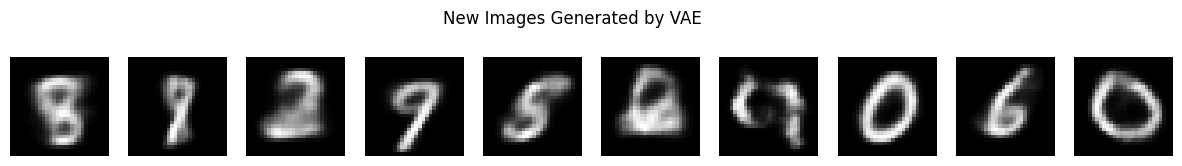

In [13]:
# Generate new images by sampling random points from the VAE latent space
n = 10
random_latent_vectors = np.random.normal(size=(n, latent_dim))
generated_images = vae_decoder.predict(random_latent_vectors, verbose=0)

plt.figure(figsize=(15, 2))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("New Images Generated by VAE")
plt.show()


## 5. Latent Space Visualization

Because the VAE uses a 2-dimensional latent space, we can visualize how test images are distributed.


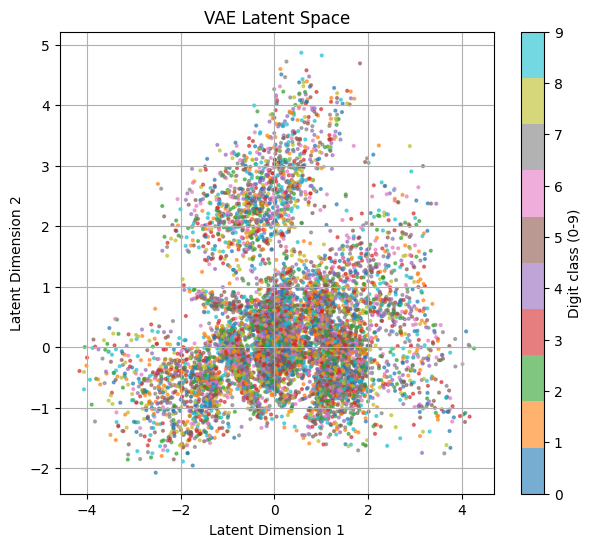

In [14]:
# Visualize VAE latent space
z_mean_all, _, _ = vae_encoder.predict(x_test, verbose=0)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    c=np.arange(len(z_mean_all)) % 10,
    cmap="tab10",
    s=4,
    alpha=0.6
)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space")
plt.colorbar(scatter, label="Digit class (0-9)")
plt.grid(True)
plt.show()


## 6. Autoencoder vs VAE Comparison

In [15]:
print("========== FINAL COMPARISON ==========")
print(f"Autoencoder Test MSE : {ae_mse:.6f}")
print(f"VAE Test MSE         : {vae_mse:.6f}")

print("\nQualitative observations:")
print("1. Autoencoder learns a deterministic compressed representation.")
print("2. Autoencoder reconstructions are generally sharper for reconstruction.")
print("3. VAE learns a smooth probabilistic latent space.")
print("4. VAE can generate new images by sampling from the latent space.")
print("5. VAE outputs can appear smoother or slightly blurrier than AE outputs.")


========== FINAL COMPARISON ==========
Autoencoder Test MSE : 0.003505
VAE Test MSE         : 0.040678

Qualitative observations:
1. Autoencoder learns a deterministic compressed representation.
2. Autoencoder reconstructions are generally sharper for reconstruction.
3. VAE learns a smooth probabilistic latent space.
4. VAE can generate new images by sampling from the latent space.
5. VAE outputs can appear smoother or slightly blurrier than AE outputs.


## 7. Result / Conclusion

The Autoencoder successfully learned a compact representation of MNIST images and reconstructed the input images.

The Variational Autoencoder also reconstructed the images and, unlike the basic Autoencoder, generated new images by sampling from its learned latent distribution.

**Conclusion:** The Autoencoder is useful for dimensionality reduction and image reconstruction, while the VAE is useful when both reconstruction and generative capabilities are required. The MSE values and displayed images can be used to compare reconstruction quality after training.
